# Импорты и общие настройки

In [20]:
import sys
import os
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import datasets
import transformers

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"Python:       {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")
print(f"datasets:     {datasets.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"torch:        {torch.__version__}")
print(f"CUDA:         {torch.version.cuda if torch.cuda.is_available() else 'Not available'}")


pandas:       2.3.3
numpy:        2.3.5
Python:       3.14.0
datasets:     4.8.4
transformers: 5.5.0
torch:        2.10.0+cpu
CUDA:         Not available


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

os.makedirs("artifacts", exist_ok=True)

Device: cpu


# Данные и первичный анализ

In [3]:
df = load_dataset("emotion")

print(df)

labels = df["train"].features["label"].names
print(f"\nКлассы ({len(labels)}): {labels}")

print("\nПримеры:")
for i in range(5):
    idx = df["train"][i]
    print(f"[{labels[idx['label']]}] {idx['text']}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры:
[sadness] i didnt feel humiliated
[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[anger] im grabbing a minute to post i feel greedy wrong
[love] i am ever feeling nostalgic about the fireplace i will know that it is still on the property
[anger] i am feeling grouchy


Что именно классифицируется? 

В датасете 6 классов (грусть, радость, любовь, злость, страх, удивление) эмоциональной окраски текста, написанного на английском языке.

Данные разбиты на train (16к) / val (2к) / test (2к)

# Токенизация

In [4]:
MODEL_NAME = "bhadresh-savani/distilbert-base-uncased-emotion"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = df.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: bhadresh-savani/distilbert-base-uncased-emotion


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [5]:
def print_tokenization(example):
    ids = example["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(ids)
    print("labels:", example["label"])
    print("Токены:")
    print(tokens)
    sep_idx = ids.index(tokenizer.sep_token_id)
    print(f"special tokens: [CLS]={tokens[0]} | [SEP]={tokens[sep_idx]}")
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])
    print("Декодированный текст по input_ids:")
    print(tokenizer.decode(example["input_ids"]))
    print("_" * 70)

for i in range(5):
    e = tokenized_datasets["train"][i]
    print_tokenization(e)



labels: 0
Токены:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
special tokens: [CLS]=[CLS] | [SEP]=[SEP]
input_ids[:20]: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1]
Декодированный текст по input_ids:
[CLS] i didnt feel humiliated [SEP]
______________________________________________________________________
labels: 0
Токены:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
special tokens: [CLS]=[CLS] | [SEP]=[SEP]
input_ids[:20]: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Декодированный текст по input_ids:
[CLS] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake [SEP]
________

In [6]:
def show_truncation():
    print("Демонстрация работы truncation")
    long_text = "В 1800-х годах, в те времена, когда не было еще ни железных, ни шоссейных дорог, ни газового, ни стеаринового света, ни пружинных низких диванов, ни мебели без лаку, ни разочарованных юношей со стеклышками, ни либеральных философов-женщин, ни милых дам-камелий, которых так много развелось в наше время, — в те наивные времена, когда из Москвы..."
    print(f"Оригинал: \"{long_text}\"\n")
    
    demo = tokenizer(long_text, max_length=10, truncation=True, padding=False)
    tokens = tokenizer.convert_ids_to_tokens(demo["input_ids"])
    
    print(f"После truncation (max_length=10):")
    print(f"Токены: {tokens}")
    print(f"input_ids: {demo['input_ids']}")
    print(f"attn_mask: {demo['attention_mask']}")
    print(f"Спецтокены: [CLS]={tokens[0]} | [SEP]={tokens[-1]}")
    print(f"Декодировано: \"{tokenizer.decode(demo['input_ids'], skip_special_tokens=True)}\"")

show_truncation()

Демонстрация работы truncation
Оригинал: "В 1800-х годах, в те времена, когда не было еще ни железных, ни шоссейных дорог, ни газового, ни стеаринового света, ни пружинных низких диванов, ни мебели без лаку, ни разочарованных юношей со стеклышками, ни либеральных философов-женщин, ни милых дам-камелий, которых так много развелось в наше время, — в те наивные времена, когда из Москвы..."

После truncation (max_length=10):
Токены: ['[CLS]', 'в', '1800', '-', 'х', 'г', '##о', '##д', '##а', '[SEP]']
input_ids: [101, 1182, 9807, 1011, 1200, 1183, 14150, 29742, 10260, 102]
attn_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Спецтокены: [CLS]=[CLS] | [SEP]=[SEP]
Декодировано: "в 1800 - х года"


# Инференс готовой модели

In [7]:
n = 5
sample_texts = df["train"]["text"][:n]
sample_labels = df["train"]["label"][:n]
label_names = df["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
true_labels = [label_names[l] for l in sample_labels]

text_clf = pipeline(
    task="text-classification",
    model=MODEL_NAME,
    tokenizer=tokenizer,
    device=device,
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [8]:
print("Инференс готовой модели\n")
for txt, true_lbl in zip(sample_texts, true_labels):
    pred = text_clf(txt)[0]
    status = "Совпадает" if pred["label"] == true_lbl else "Не совпадает"
    
    print(f"Текст: \"{txt[:50]}{'...' if len(txt)>70 else ''}\"")
    print(f"Истинная метка: {true_lbl}")
    print(f"Предсказание готовой модели: {pred['label']} (уверенность: {pred['score']:.2f})")
    print(f"Статус: {status}")
    print("=" * 65)

Инференс готовой модели

Текст: "i didnt feel humiliated"
Истинная метка: sadness
Предсказание готовой модели: sadness (уверенность: 1.00)
Статус: Совпадает
Текст: "i can go from feeling so hopeless to so damned hop..."
Истинная метка: sadness
Предсказание готовой модели: sadness (уверенность: 1.00)
Статус: Совпадает
Текст: "im grabbing a minute to post i feel greedy wrong"
Истинная метка: anger
Предсказание готовой модели: anger (уверенность: 1.00)
Статус: Совпадает
Текст: "i am ever feeling nostalgic about the fireplace i ..."
Истинная метка: love
Предсказание готовой модели: love (уверенность: 1.00)
Статус: Совпадает
Текст: "i am feeling grouchy"
Истинная метка: anger
Предсказание готовой модели: anger (уверенность: 1.00)
Статус: Совпадает


Выбранная модель хорошо обобщает данные и успешно распознает 6 классов эмоций в текстах. Семантика классов совпадает, классы датасета и модели одинаковые.

# Fine-tuning для классификации текста

In [9]:
MODEL_NAME_FINE_TUNE = "google/electra-small-discriminator"

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_FINE_TUNE,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

input_ids: shape=(3, 23)
token_type_ids: shape=(3, 23)
attention_mask: shape=(3, 23)
labels: shape=(3,)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-small-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: ElectraForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [11]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

C:\Users\danya\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.716665,0.785337,0.723000,0.469848,0.661581
2,0.765897,0.590940,0.834000,0.723564,0.827124


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\danya\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=2000, training_loss=0.9619161043465138, metrics={'train_runtime': 1204.9022, 'train_samples_per_second': 26.558, 'train_steps_per_second': 1.66, 'total_flos': 86459813877312.0, 'train_loss': 0.9619161043465138, 'epoch': 2.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.7974,1.0527,1.9990e-05,0.002,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.7786,1.5647,1.9970e-05,0.004,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.7857,1.1049,1.9950e-05,0.006,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.7788,1.5797,1.9930e-05,0.008,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.7675,1.2788,1.9910e-05,0.010,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.7798,1.1393,1.9890e-05,0.012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.7634,1.2627,1.9870e-05,0.014,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.7295,1.6132,1.9850e-05,0.016,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.7490,1.1130,1.9830e-05,0.018,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.7476,1.2042,1.9810e-05,0.020,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


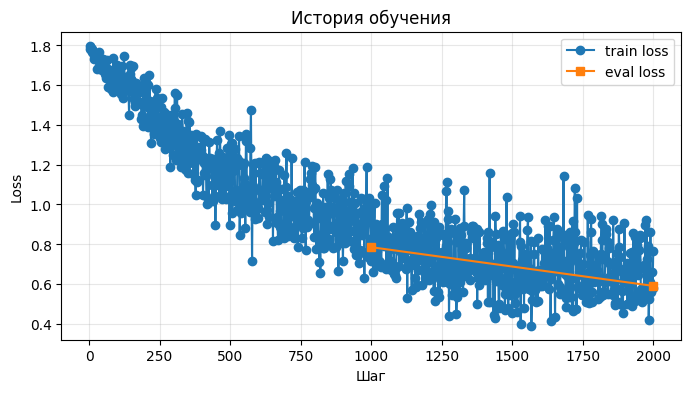

saved: ./artifacts/training_curves.png


In [12]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(f"./artifacts/training_curves.png")
plt.show()

print(f"saved: ./artifacts/training_curves.png")

# Оценка качества и краткий анализ ошибок

In [13]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

C:\Users\danya\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\danya\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.5909
eval_accuracy: 0.8340
eval_f1_macro: 0.7236
eval_f1_weighted: 0.8271
eval_runtime: 14.2908
eval_samples_per_second: 139.9500
eval_steps_per_second: 8.7470
epoch: 2.0000

Test metrics:
eval_loss: 0.5754
eval_accuracy: 0.8380
eval_f1_macro: 0.7001
eval_f1_weighted: 0.8278
eval_runtime: 14.8163
eval_samples_per_second: 134.9860
eval_steps_per_second: 8.4370
epoch: 2.0000


C:\Users\danya\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.92      0.95      0.93       581
         joy       0.91      0.94      0.93       695
        love       0.78      0.73      0.75       159
       anger       0.77      0.56      0.65       275
        fear       0.60      0.86      0.70       224
    surprise       1.00      0.14      0.24        66

    accuracy                           0.84      2000
   macro avg       0.83      0.69      0.70      2000
weighted avg       0.85      0.84      0.83      2000



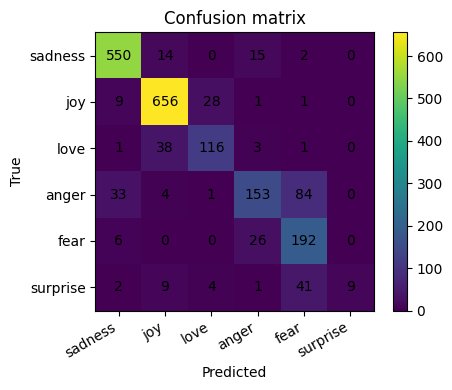

saved: ./artifacts/confusion_matrix.png


,text,true_label,pred_label,confidence,prob_sadness,prob_joy,prob_love,prob_anger,prob_fear,prob_surprise
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.8505,0.8505,0.0246,0.0089,0.0737,0.0317,0.0105
1,i don t feel particularly agitated,sadness,fear,0.4013,0.0744,0.0258,0.0355,0.3380,0.4013,0.1249
2,im not sure the feeling of loss will ever go away but it may dull to a sweet feeling of nostalgia at what i shared in this life with my ...,sadness,joy,0.3927,0.0448,0.3927,0.3727,0.0500,0.0540,0.0858
3,ive been missing him and feeling so restless at home thinking of him,joy,fear,0.4087,0.0698,0.0267,0.0376,0.3275,0.4087,0.1297
4,i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change,sadness,sadness,0.5448,0.5448,0.0115,0.0105,0.2972,0.1114,0.0246
5,i stood up to you i finally stood up to you and now i feel like im being punished if i could go back and do it again,fear,sadness,0.8450,0.8450,0.0185,0.0080,0.0849,0.0331,0.0106
6,i woke up yesterday monday morning feeling a little depressed,anger,sadness,0.8489,0.8489,0.0220,0.0085,0.0775,0.0323,0.0108
7,i think they have always been proponents of the idea and it is just slightly possible that his feelings for a particularly charming new ...,joy,joy,0.8995,0.0111,0.8995,0.0668,0.0061,0.0072,0.0093
8,i feel privileged in my world,joy,joy,0.9204,0.0155,0.9204,0.0437,0.0062,0.0070,0.0072
9,i have a feeling that people are using it more than they need to and enjoying the feeling as it flies carefree off the tongue but that i...,anger,joy,0.8945,0.0111,0.8945,0.0718,0.0063,0.0073,0.0091


In [14]:
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(f"./artifacts/confusion_matrix.png")
plt.show()

print(f"saved: ./artifacts/confusion_matrix.png")

def predict_texts(texts: List[str]) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    true_labels = [id2label[idx] for idx in df["test"]["label"][:len(texts)]]
    
    rows = []
    for i, (text, pred_id, prob_vector) in enumerate(zip(texts, pred_ids, probs)):
        row = {
            "text": text,
            "true_label": true_labels[i],
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        rows.append(row)

    return pd.DataFrame(rows)

new_texts = df["test"]["text"][:100:10]

display(predict_texts(new_texts))

В выборке из 100 элементов каждого десятого, 5 верно предсказали метки, но другая пятерка уже имеет ошибки. Модель иногда путает эмоции (негативные и позитивные) (страх и злость, радость и любовь). Наибольшая неопределнность возникает в тексте, где смешанная или слабая эмоциональная окраска. 

In [15]:
results = [
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i didnt feel humiliated',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i can go from feeling so hopeless to so damned hopeful just from being...',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'im grabbing a minute to post i feel greedy wrong',
        'true_label': 'anger',
        'pred_label': 'anger',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i am ever feeling nostalgic about the fireplace i will know that it is...',
        'true_label': 'love',
        'pred_label': 'love',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i am feeling grouchy',
        'true_label': 'anger',
        'pred_label': 'anger',
        'confidence': 1.0,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'im feeling rather rotten so im not very ambitious right now',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 0.8505,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i don t feel particularly agitated',
        'true_label': 'sadness',
        'pred_label': 'fear',
        'confidence': 0.4013,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'im not sure the feeling of loss will ever go away but it may dull to a sweet feeling of nostalgia at what i shared in this life with my ...',
        'true_label': 'sadness',
        'pred_label': 'joy',
        'confidence': 0.3927,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'ive been missing him and feeling so restless at home thinking of him',
        'true_label': 'joy',
        'pred_label': 'fear',
        'confidence': 0.4087,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 0.5448,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i stood up to you i finally stood up to you and now i feel like im being punished if i could go back and do it again',
        'true_label': 'fear',
        'pred_label': 'sadness',
        'confidence': 0.8450,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i woke up yesterday monday morning feeling a little depressed',
        'true_label': 'anger',
        'pred_label': 'sadness',
        'confidence': 0.8489,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i think they have always been proponents of the idea and it is just slightly possible that his feelings for a particularly charming new ..',
        'true_label': 'joy',
        'pred_label': 'joy',
        'confidence': 0.8995,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i feel privileged in my world',
        'true_label': 'joy',
        'pred_label': 'joy',
        'confidence': 0.9204,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i have a feeling that people are using it more than they need to and enjoying the feeling as it flies carefree off the tongue but that i...',
        'true_label': 'anger',
        'pred_label': 'joy',
        'confidence': 0.8945,
    },
]

df_sample_predictions = pd.DataFrame(results)

output_path = './artifacts/sample_predictions.csv'

df_sample_predictions.to_csv(output_path, index=False, encoding='utf-8')

print(f"saved: ./artifacts/sample_predictions.csv")

saved: ./artifacts/sample_predictions.csv
